In [1]:
# ── Cell 1 · Imports & load data from disk ────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

# Load from disk — no need to re-download
log_returns = pd.read_csv(
    "../data/raw/log_returns.csv",
    index_col=0,
    parse_dates=True,
)

raw_prices = pd.read_csv(
    "../data/raw/prices_raw.csv",
    index_col=0,
    parse_dates=True,
)

print(f"Log returns : {log_returns.shape}")
print(f"Raw prices  : {raw_prices.shape}")
print(f"Date range  : {log_returns.index[0].date()} → {log_returns.index[-1].date()}")
print("\nData loaded from disk ✓")

Log returns : (2764, 11)
Raw prices  : (2765, 11)
Date range  : 2015-01-05 → 2025-12-30

Data loaded from disk ✓


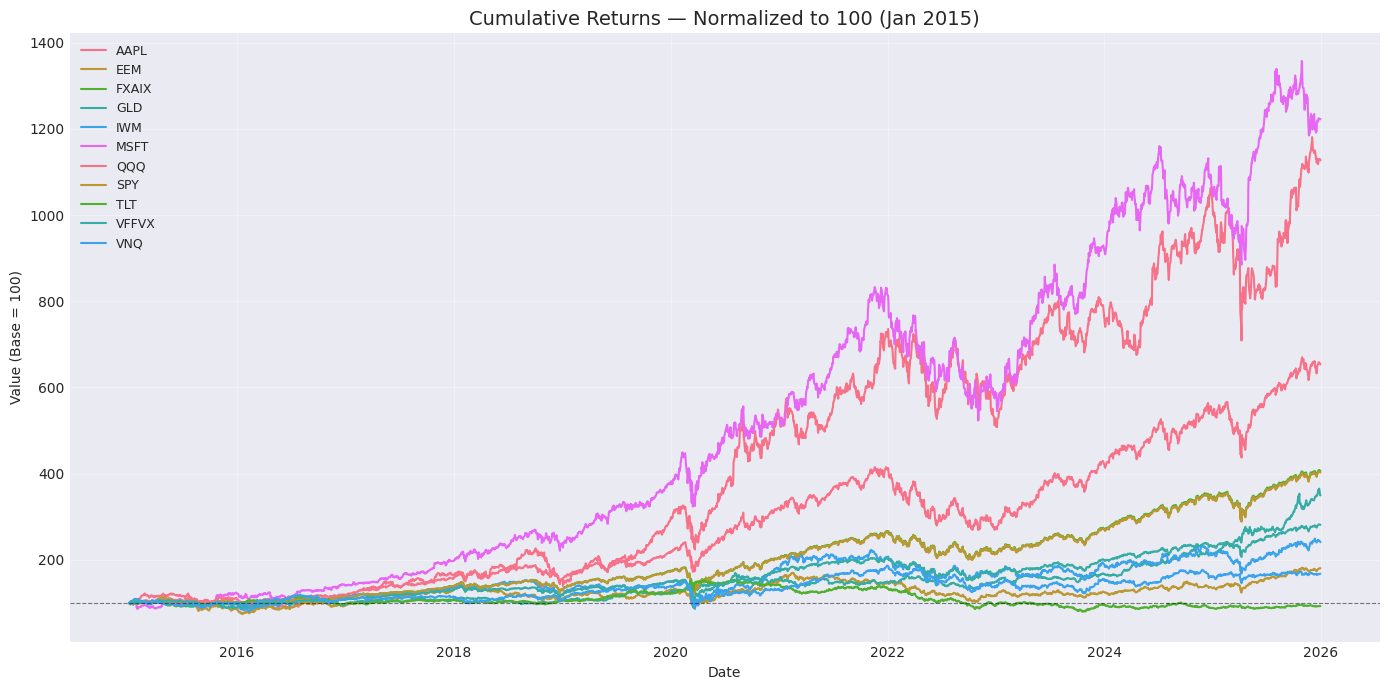

Saved: 01_cumulative_returns.png ✓


In [2]:
# ── Cell 2 · Cumulative returns normalized to 100 ─────────────────────────

# Normalize all assets to 100 at start date
# Answers: if you invested $100 in each asset in Jan 2015, what would you have today?

normalized = (raw_prices / raw_prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 7))

for ticker in normalized.columns:
    ax.plot(normalized.index, normalized[ticker], label=ticker, linewidth=1.5)

ax.axhline(y=100, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_title("Cumulative Returns — Normalized to 100 (Jan 2015)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Value (Base = 100)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/01_cumulative_returns.png", dpi=150)
plt.show()

print("Saved: 01_cumulative_returns.png ✓")

In [3]:
# ── Cell 3 · Risk & return statistics ─────────────────────────────────────

TRADING_DAYS = 252  # standard annualization factor

# Annualized return: daily mean × 252
ann_return = log_returns.mean() * TRADING_DAYS

# Annualized volatility: daily std × sqrt(252)
# Why sqrt? Variance scales linearly, std scales with square root
ann_volatility = log_returns.std() * np.sqrt(TRADING_DAYS)

# Sharpe ratio: return per unit of risk (assuming risk-free rate ~0 for simplicity)
# We'll add proper risk-free rate in project 2
sharpe = ann_return / ann_volatility

# Build summary table
stats = pd.DataFrame({
    "Ann. Return (%)": (ann_return * 100).round(2),
    "Ann. Volatility (%)": (ann_volatility * 100).round(2),
    "Sharpe Ratio": sharpe.round(3),
}).sort_values("Sharpe Ratio", ascending=False)

print("=== Risk & Return Summary (2015–2025) ===\n")
print(stats.to_string())

=== Risk & Return Summary (2015–2025) ===

       Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio
MSFT             22.83                26.87         0.850
QQQ              17.11                22.02         0.777
GLD              11.41                14.76         0.773
AAPL             22.08                28.82         0.766
FXAIX            12.78                17.96         0.712
SPY              12.70                17.83         0.712
VFFVX             9.43                15.01         0.629
IWM               8.02                22.63         0.354
EEM               5.40                20.50         0.263
VNQ               4.73                20.69         0.229
TLT              -0.69                15.04        -0.046


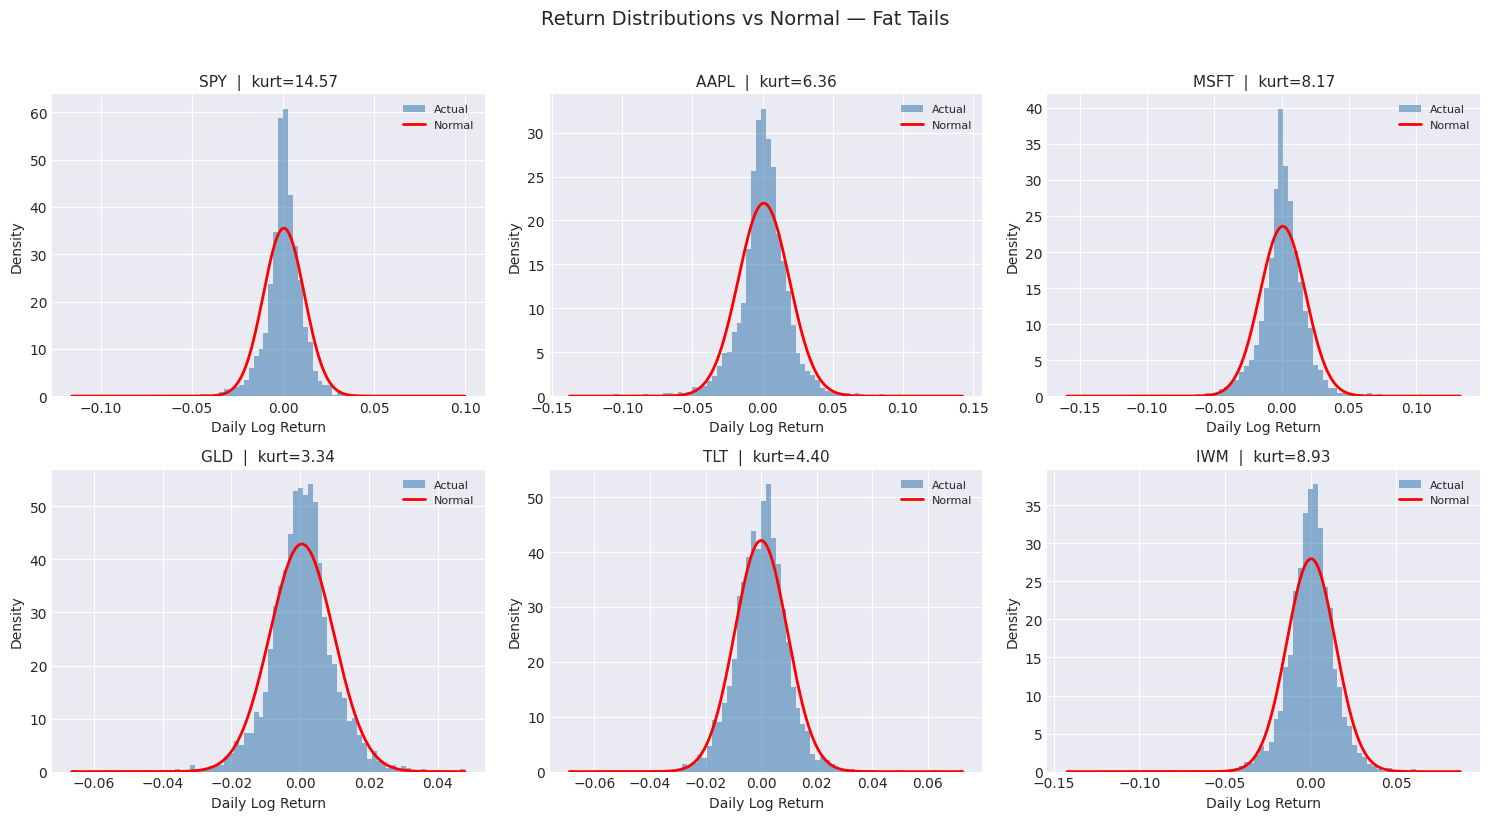

Saved: 02_return_distributions.png ✓


In [4]:
# ── Cell 4 · Return distributions with normal curve overlay ───────────────

from scipy import stats as scipy_stats

# Select key tickers for clarity
TICKERS_PLOT = ["SPY", "AAPL", "MSFT", "GLD", "TLT", "IWM"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS_PLOT):
    ax = axes[i]
    returns = log_returns[ticker].dropna()
    
    # Histogram of actual returns
    ax.hist(returns, bins=80, density=True, alpha=0.6,
            color="steelblue", label="Actual")
    
    # Normal distribution overlay
    mu, sigma = returns.mean(), returns.std()
    x = np.linspace(returns.min(), returns.max(), 200)
    ax.plot(x, scipy_stats.norm.pdf(x, mu, sigma),
            color="red", linewidth=2, label="Normal")
    
    # Actual stats
    kurt = returns.kurt()
    ax.set_title(f"{ticker}  |  kurt={kurt:.2f}", fontsize=11)
    ax.set_xlabel("Daily Log Return")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Return Distributions vs Normal — Fat Tails", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/02_return_distributions.png", dpi=150)
plt.show()

print("Saved: 02_return_distributions.png ✓")

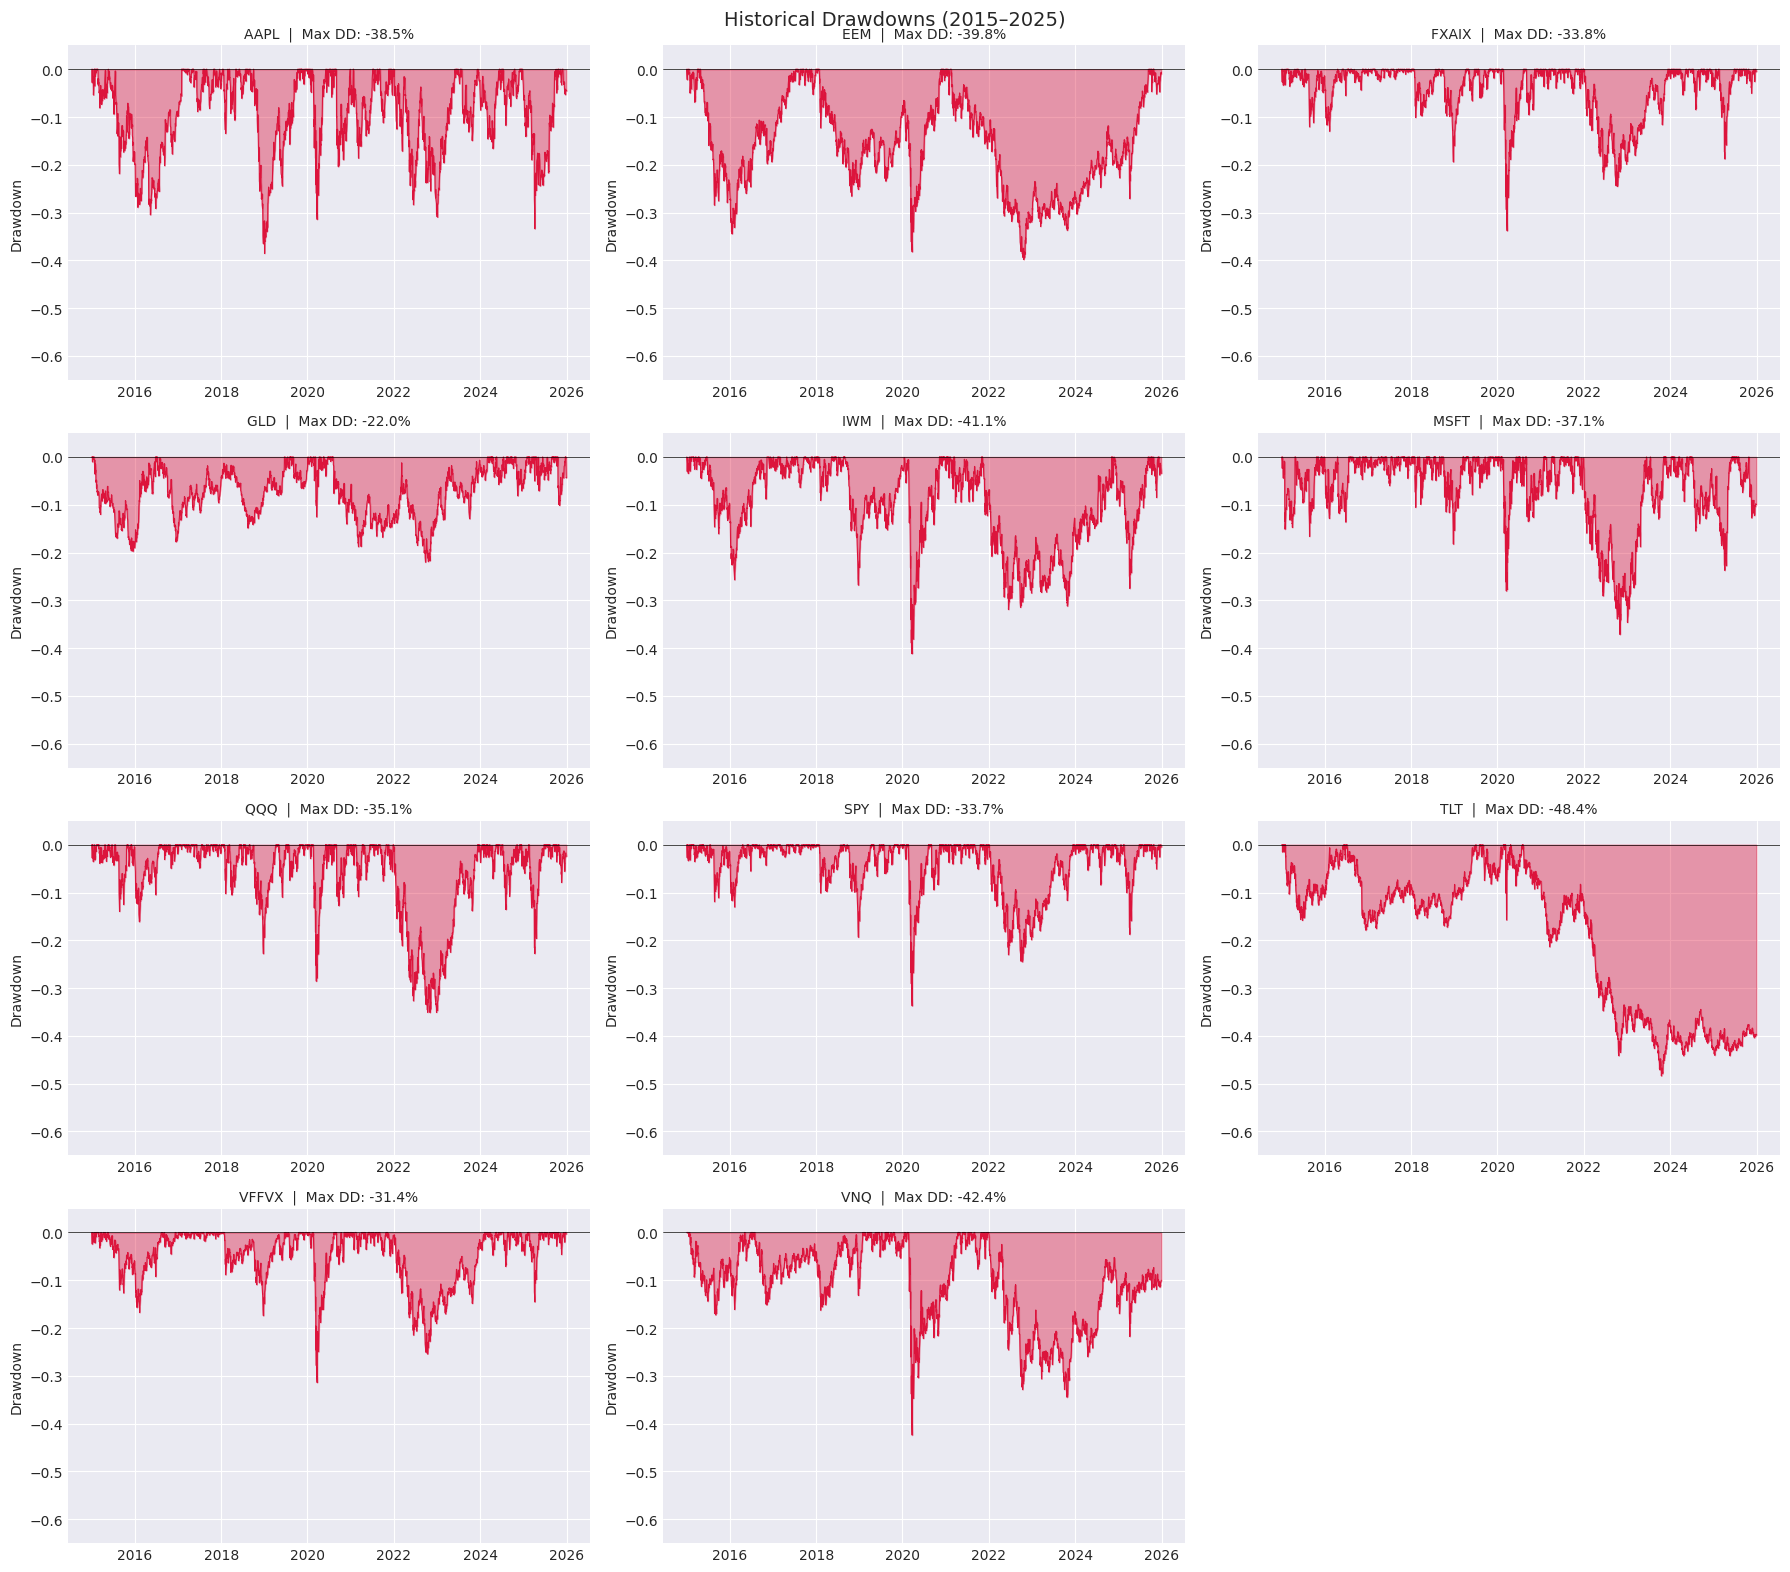

Saved: 03_drawdowns.png ✓


In [5]:
# ── Cell 5 · Historical Drawdown ──────────────────────────────────────────

# Drawdown: how far is each asset from its previous all-time high?
# Formula: (current_price - rolling_max) / rolling_max

def calculate_drawdown(prices):
    rolling_max = prices.cummax()
    drawdown = (prices - rolling_max) / rolling_max
    return drawdown

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, ticker in enumerate(raw_prices.columns):
    ax = axes[i]
    dd = calculate_drawdown(raw_prices[ticker])
    
    ax.fill_between(dd.index, dd, 0, alpha=0.4, color="crimson")
    ax.plot(dd.index, dd, color="crimson", linewidth=0.8)
    
    max_dd = dd.min()
    ax.set_title(f"{ticker}  |  Max DD: {max_dd:.1%}", fontsize=10)
    ax.set_ylabel("Drawdown")
    ax.set_ylim(-0.65, 0.05)
    ax.axhline(y=0, color="black", linewidth=0.5)

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle("Historical Drawdowns (2015–2025)", fontsize=14)
plt.tight_layout()
plt.savefig("../reports/figures/03_drawdowns.png", dpi=150)
plt.show()

print("Saved: 03_drawdowns.png ✓")

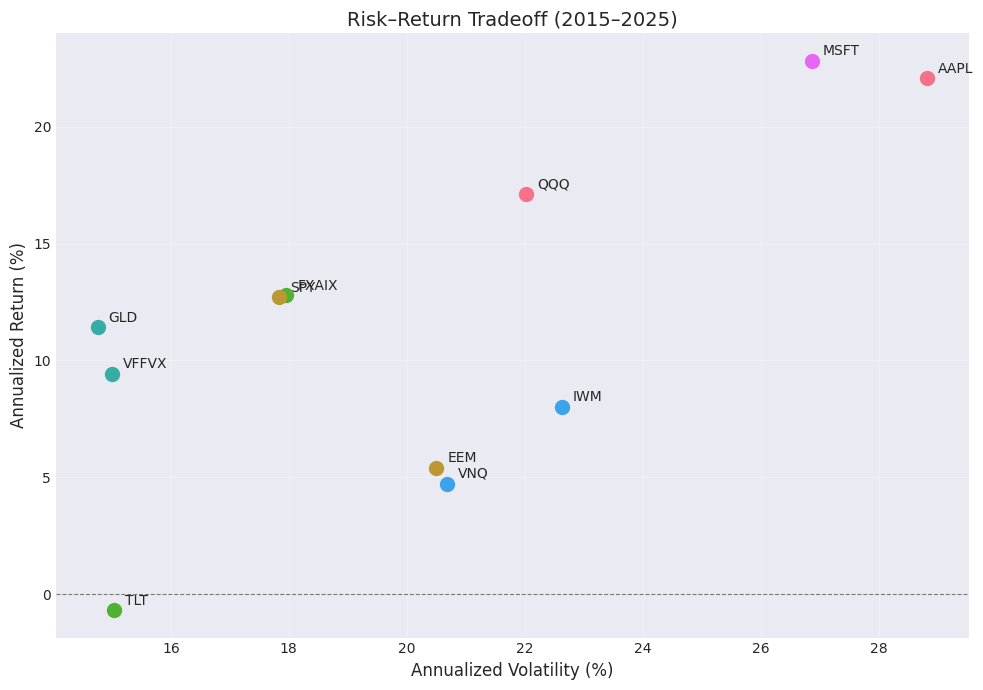

Saved: 04_risk_return_scatter.png ✓


In [6]:
# ── Cell 6 · Risk-Return Scatter ──────────────────────────────────────────
# Visualizes the risk-return tradeoff for each asset
# Each dot = one asset. X = risk (volatility), Y = return
# Assets in the upper-left are most efficient (high return, low risk)

fig, ax = plt.subplots(figsize=(10, 7))

for ticker in log_returns.columns:
    x = ann_volatility[ticker] * 100
    y = ann_return[ticker] * 100
    ax.scatter(x, y, s=100, zorder=5)
    ax.annotate(ticker, (x, y),
                textcoords="offset points",
                xytext=(8, 4),
                fontsize=10)

ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("Annualized Volatility (%)", fontsize=12)
ax.set_ylabel("Annualized Return (%)", fontsize=12)
ax.set_title("Risk–Return Tradeoff (2015–2025)", fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/04_risk_return_scatter.png", dpi=150)
plt.show()

print("Saved: 04_risk_return_scatter.png ✓")